In [4]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

def bayesian_update(prior, sensitivity, false_positive_rate):
    """Posterior P(Disease | positive test) via Bayes' theorem."""
    p_positive = sensitivity * prior + false_positive_rate * (1 - prior)
    return (sensitivity * prior) / p_positive

prior, sens, fpr = 0.05, 0.90, 0.07
post = bayesian_update(prior, sens, fpr)
print(f"Single example: prior={prior}, sensitivity={sens}, false-positive={fpr}")
print(f"Posterior P(Disease | positive) = {post:.4f}  ({post*100:.2f}%)")

Single example: prior=0.05, sensitivity=0.9, false-positive=0.07
Posterior P(Disease | positive) = 0.4036  (40.36%)


In [5]:
patients = [
    {"id":"P001","prior":0.05,"sensitivity":0.90,"fpr":0.07},
    {"id":"P002","prior":0.20,"sensitivity":0.95,"fpr":0.05},
    {"id":"P003","prior":0.40,"sensitivity":0.85,"fpr":0.10},
    {"id":"P004","prior":0.15,"sensitivity":0.92,"fpr":0.06},
]
def risk_level(p):
    if p >= 0.80: return "HIGH",     "Immediate treatment"
    if p >= 0.50: return "MODERATE", "Further investigation"
    return            "LOW",      "Continue monitoring"

print(f"{'ID':<6}{'Prior':<7}{'Posterior':<12}{'Risk':<10}Recommendation")
print("-" * 60)
for pt in patients:
    p = bayesian_update(pt["prior"], pt["sensitivity"], pt["fpr"])
    risk, rec = risk_level(p)
    print(f"{pt['id']:<6}{pt['prior']:<7}{p*100:>7.2f}%    {risk:<10}{rec}")

ID    Prior  Posterior   Risk      Recommendation
------------------------------------------------------------
P001  0.05     40.36%    LOW       Continue monitoring
P002  0.2      82.61%    HIGH      Immediate treatment
P003  0.4      85.00%    HIGH      Immediate treatment
P004  0.15     73.02%    MODERATE  Further investigation


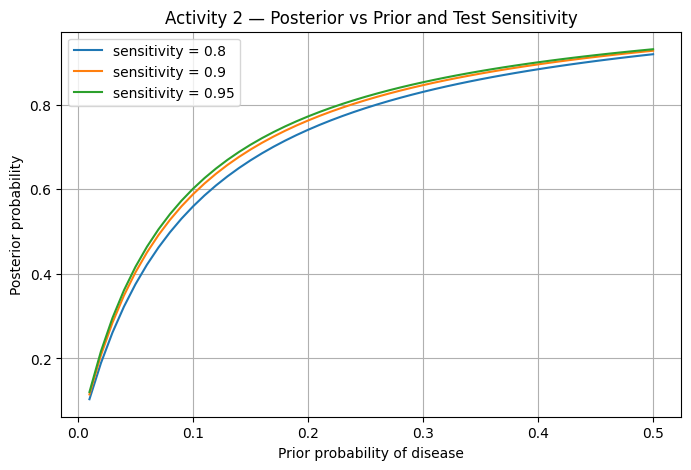

The prior has the largest effect on the posterior.


In [6]:
priors = np.linspace(0.01, 0.50, 50)
plt.figure(figsize=(8,5))
for s in [0.80, 0.90, 0.95]:
    plt.plot(priors, [bayesian_update(p, s, 0.07) for p in priors], label=f"sensitivity = {s}")
plt.xlabel("Prior probability of disease"); plt.ylabel("Posterior probability")
plt.title("Activity 2 — Posterior vs Prior and Test Sensitivity")
plt.legend(); plt.grid(True); plt.show()
print("The prior has the largest effect on the posterior.")

Activity-3

In [7]:
import numpy as np, random
import matplotlib.pyplot as plt
np.random.seed(0); random.seed(0)

states  = ["Critical", "Stable", "Recovered"]
actions = ["Medication", "Surgery", "Observation"]
nS, nA = len(states), len(actions)

P = {
    0: {0:[0.4,0.6,0.0], 1:[0.2,0.7,0.1], 2:[0.8,0.2,0.0]},
    1: {0:[0.1,0.4,0.5], 1:[0.3,0.5,0.2], 2:[0.1,0.8,0.1]},
    2: {0:[0.0,0.1,0.9], 1:[0.0,0.2,0.8], 2:[0.0,0.0,1.0]},
}
reward_for_state = {0: -10, 1: 5, 2: 20}

def step(s, a):
    s_next = np.random.choice(nS, p=P[s][a])
    return s_next, reward_for_state[s_next]

alpha, gamma, epsilon, episodes = 0.1, 0.9, 0.2, 500
Q = np.zeros((nS, nA))
episode_rewards = []
for ep in range(episodes):
    s = random.randint(0, nS - 1); total = 0
    for t in range(20):
        a = random.randint(0, nA-1) if random.random() < epsilon else int(np.argmax(Q[s]))
        s_next, r = step(s, a)
        Q[s, a] += alpha * (r + gamma * np.max(Q[s_next]) - Q[s, a])
        total += r; s = s_next
        if s == 2 and a == 2: break
    episode_rewards.append(total)

print("Learned Q-table:\n", np.round(Q, 2))
print("\nOptimal policy:")
for s in range(nS):
    print(f"  {states[s]:<10} -> {actions[int(np.argmax(Q[s]))]}")

Learned Q-table:
 [[137.25 173.01 129.97]
 [193.12 164.18 168.01]
 [192.7  190.59 199.52]]

Optimal policy:
  Critical   -> Surgery
  Stable     -> Medication
  Recovered  -> Observation


Random policy   average reward : 19.20
Q-learning      average reward : 22.07
Improvement                    : 14.9%


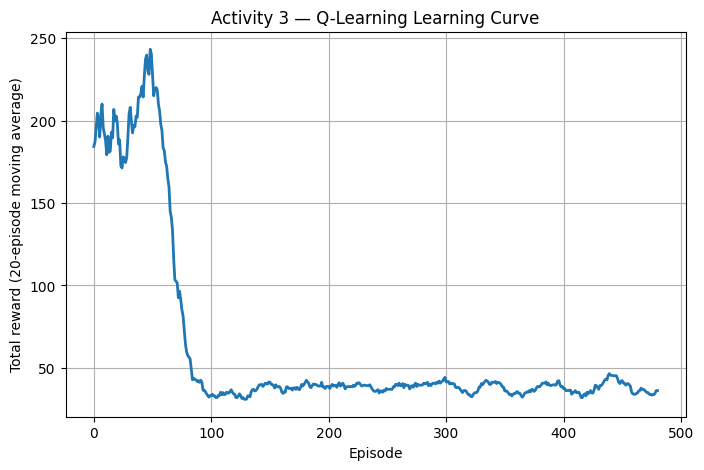

In [8]:
def run_policy(policy_fn, runs=500):
    totals = []
    for _ in range(runs):
        s = random.randint(0, nS-1); r_sum = 0
        for t in range(20):
            a = policy_fn(s); s, r = step(s, a); r_sum += r
            if s == 2: break
        totals.append(r_sum)
    return np.mean(totals)

random_avg = run_policy(lambda s: random.randint(0, nA-1))
qlearn_avg = run_policy(lambda s: int(np.argmax(Q[s])))
print(f"Random policy   average reward : {random_avg:.2f}")
print(f"Q-learning      average reward : {qlearn_avg:.2f}")
print(f"Improvement                    : {(qlearn_avg-random_avg)/abs(random_avg)*100:.1f}%")

smooth = np.convolve(episode_rewards, np.ones(20)/20, mode="valid")
plt.figure(figsize=(8,5)); plt.plot(smooth, linewidth=2)
plt.xlabel("Episode"); plt.ylabel("Total reward (20-episode moving average)")
plt.title("Activity 3 — Q-Learning Learning Curve"); plt.grid(True); plt.show()

Activity-4


In [9]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1)

num_patients = 10
service_times = np.random.randint(5, 45, num_patients)

def fitness(order):
    total, waited = 0, 0
    for p in order:
        waited += service_times[p]; total += waited
    return total

def decode(position):
    return np.argsort(position)

n_particles, iterations = 20, 50
w, c1, c2 = 0.7, 2.0, 2.0
dim = num_patients

X = np.random.rand(n_particles, dim); V = np.zeros((n_particles, dim))
pbest = X.copy(); pbest_fit = np.array([fitness(decode(x)) for x in X])
g = int(np.argmin(pbest_fit)); gbest, gbest_fit = pbest[g].copy(), pbest_fit[g]

history = []
for it in range(iterations):
    for i in range(n_particles):
        r1, r2 = np.random.rand(dim), np.random.rand(dim)
        V[i] = w*V[i] + c1*r1*(pbest[i]-X[i]) + c2*r2*(gbest-X[i])
        X[i] = X[i] + V[i]
        f = fitness(decode(X[i]))
        if f < pbest_fit[i]:
            pbest_fit[i], pbest[i] = f, X[i].copy()
            if f < gbest_fit: gbest_fit, gbest = f, X[i].copy()
    history.append(gbest_fit)

best_order = decode(gbest)
print("Service times (min):", service_times.tolist())
print("Optimised order (slot -> patient):", (best_order + 1).tolist())
print("Best fitness (total cumulative wait):", gbest_fit)

Service times (min): [42, 17, 13, 14, 16, 10, 20, 5, 21, 6]
Optimised order (slot -> patient): [8, 10, 6, 3, 4, 5, 2, 7, 9, 1]
Best fitness (total cumulative wait): 651


Random search best fitness : 694
PSO best fitness           : 651
Improvement                : 6.2%


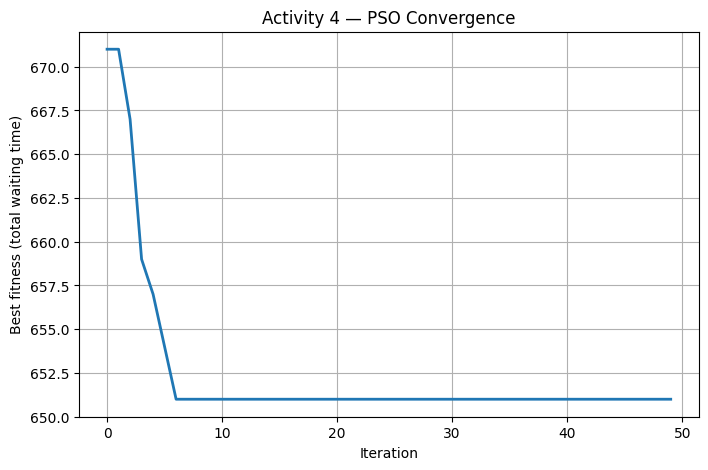

In [10]:
random_best = min(fitness(np.random.permutation(num_patients)) for _ in range(1000))
print(f"Random search best fitness : {random_best}")
print(f"PSO best fitness           : {gbest_fit}")
print(f"Improvement                : {(random_best-gbest_fit)/random_best*100:.1f}%")

plt.figure(figsize=(8,5)); plt.plot(history, linewidth=2)
plt.xlabel("Iteration"); plt.ylabel("Best fitness (total waiting time)")
plt.title("Activity 4 — PSO Convergence"); plt.grid(True); plt.show()

Activity-5


In [18]:
!pip install -q transformers sentencepiece

In [19]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("Loaded", MODEL_NAME, "on", device)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loaded google/flan-t5-base on cpu


In [20]:
import os
CSV = "healthcare_dataset.csv"

# Upload your real file when the button appears:
from google.colab import files
files.upload()

if os.path.exists(CSV):
    df = pd.read_csv(CSV); print("Loaded real dataset:", df.shape)
else:
    np.random.seed(7)
    dx = ["Hypertension","Diabetes","Coronary Artery Disease","Hyperlipidemia","Healthy"]
    tx = ["Observation","Medication and diet","Surgical follow-up","Statins and review","Routine check-up"]
    rows=[]
    for i in range(20):
        d=np.random.randint(len(dx))
        rows.append({"Patient_ID":i+1,"Age":int(np.random.randint(25,80)),
                     "Gender":np.random.choice(["Male","Female"]),
                     "Blood_Pressure":int(np.random.randint(90,160)),
                     "Heart_Rate":int(np.random.randint(60,100)),
                     "Cholesterol_Level":int(np.random.randint(150,300)),
                     "BMI":round(float(np.random.uniform(18,36)),1),
                     "Diagnosis":dx[d],"Treatment_Plan":tx[d],
                     "Follow_Up_Date":"2024-01-%02d"%(i+1)})
    df = pd.DataFrame(rows); print("Synthetic sample:", df.shape)
df = df.fillna("Unknown").drop_duplicates()
df.head()

Saving healthcare_dataset.csv to healthcare_dataset.csv
Loaded real dataset: (500, 10)


,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04
4,5,60,Male,130,96,206,39.3,Diabetes,Unknown,2024-01-05


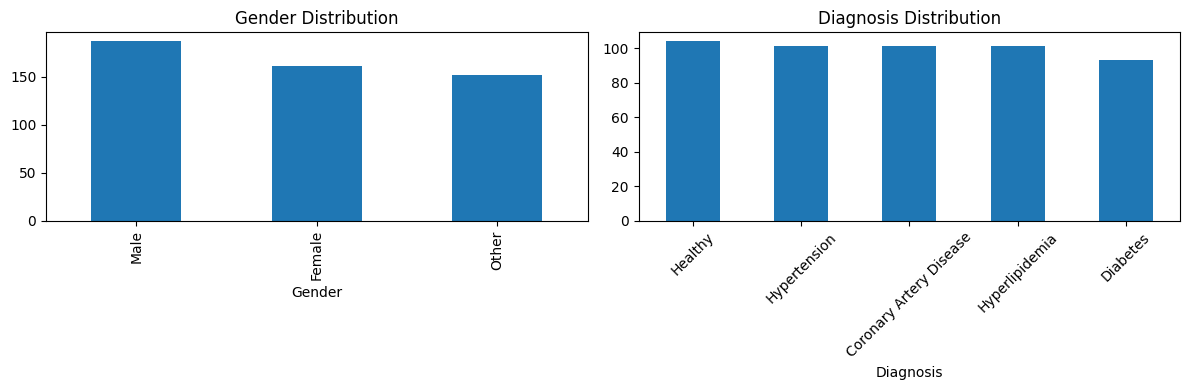

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
df["Gender"].value_counts().plot(kind="bar", ax=ax[0], title="Gender Distribution")
df["Diagnosis"].value_counts().plot(kind="bar", ax=ax[1], title="Diagnosis Distribution")
ax[1].tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

In [22]:
def make_prompt(r):
    return ("Write a concise professional clinical summary in 2 to 3 sentences "
            "for the following patient. "
            f"Age {r['Age']}, {r['Gender']}, blood pressure {r['Blood_Pressure']}, "
            f"heart rate {r['Heart_Rate']}, cholesterol {r['Cholesterol_Level']}, "
            f"BMI {r['BMI']}, diagnosis {r['Diagnosis']}, "
            f"treatment plan {r['Treatment_Plan']}, follow up {r['Follow_Up_Date']}.")

def generate_summary(r):
    inp = tokenizer(make_prompt(r), return_tensors="pt", truncation=True, max_length=512).to(device)
    out = model.generate(**inp, max_new_tokens=120, min_new_tokens=30,
                         num_beams=4, no_repeat_ngram_size=2, early_stopping=True)
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()

print("SANITY CHECK:\n", generate_summary(df.iloc[0]))

SANITY CHECK:
 Hypertension: A patient with blood pressure 97, heart rate 90, cholesterol 282, BMI 35.2, diagnosis and follow up 2024-01-01.


In [23]:
df_small = df.head(20).copy()
df_small["AI_Clinical_Summary"] = df_small.apply(generate_summary, axis=1)
for _, r in df_small.iterrows():
    print(f"Patient {r['Patient_ID']} ({r['Diagnosis']}): {r['AI_Clinical_Summary']}\n")

Patient 1 (Hypertension): Hypertension: A patient with blood pressure 97, heart rate 90, cholesterol 282, BMI 35.2, diagnosis and follow up 2024-01-01.

Patient 2 (Healthy): Blood pressure 129, heart rate 80, cholesterol 169, BMI 32.3, diagnosis Healthy, treatment plan Medication, follow up 2024-01-02.

Patient 3 (Diabetes): A 14-year-old male with diabetes has blood pressure 172, heart rate 76, cholesterol 157, BMI 29.9 and a diagnosis of diabetes.

Patient 4 (Coronary Artery Disease): A 71-year-old woman with Coronary Artery Disease has a blood pressure of 131, heart rate 82, cholesterol 150, BMI 19.4 and coronary artery disease.

Patient 5 (Diabetes): A 60-year-old male with diabetes has a blood pressure of 130, heart rate of 96, cholesterol 206, BMI 39.3 and diabetes.

Patient 6 (Healthy): Blood pressure, heart rate, cholesterol, BMI, diagnosis Healthy, treatment plan Observation, follow-up 2024-01-06.

Patient 7 (Hypertension): Hypertension: A case report from a 82-year-old woman 

 Patient_ID               Diagnosis  Word_Count  Char_Length
          1            Hypertension          19          125
          2                 Healthy          18          129
          3                Diabetes          21          126
          4 Coronary Artery Disease          24          147
          5                Diabetes          21          119
          6                 Healthy          13          114
          7            Hypertension          27          190
          8          Hyperlipidemia          23          172
          9                 Healthy          18          126
         10            Hypertension          17          116
         11 Coronary Artery Disease          22          148
         12                Diabetes          21          145
         13                Diabetes          21          146
         14                Diabetes          21          139
         15 Coronary Artery Disease          24          143
         16            H

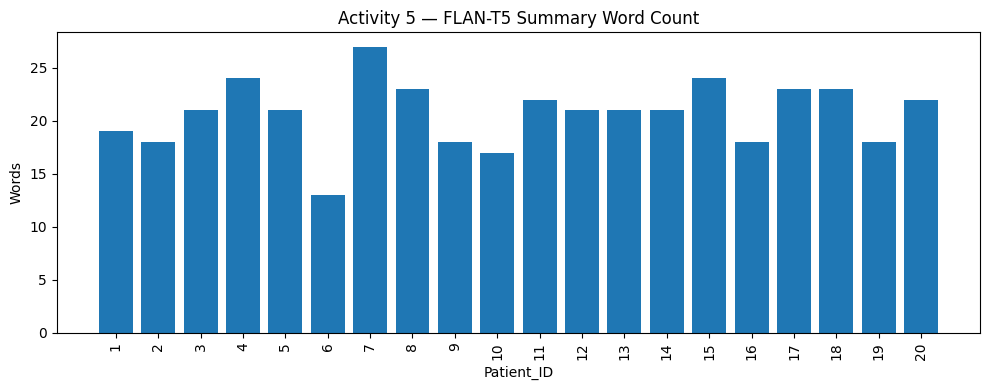

Saved: Healthcare_AI_Clinical_Summaries.csv


In [24]:
df_small["Char_Length"] = df_small["AI_Clinical_Summary"].str.len()
df_small["Word_Count"]  = df_small["AI_Clinical_Summary"].str.split().apply(len)

print(df_small[["Patient_ID","Diagnosis","Word_Count","Char_Length"]].to_string(index=False))
print("\nAverage words per summary:", round(df_small["Word_Count"].mean(),1))
print("Empty summaries:", int((df_small["Word_Count"]==0).sum()))

plt.figure(figsize=(10,4))
plt.bar(df_small["Patient_ID"].astype(str), df_small["Word_Count"])
plt.xticks(rotation=90); plt.xlabel("Patient_ID"); plt.ylabel("Words")
plt.title("Activity 5 — FLAN-T5 Summary Word Count"); plt.tight_layout(); plt.show()

df_small.to_csv("Healthcare_AI_Clinical_Summaries.csv", index=False)
print("Saved: Healthcare_AI_Clinical_Summaries.csv")

Activity-6

In [ ]:
# Activity 6 — Human Factors, Ethics, Privacy, Security, Safety and Deployment Audit
**LO1, LO4, LO5, LO6**

## 6.1 Selected System or Artefact
This audit evaluates the integrated Medical Diagnosis Support Agent developed across Activities 3–5,
together with the Bayesian diagnostic reasoning of Activity 2. The system combines Bayesian updating for diagnosis under uncertainty,
Q-learning for adaptive treatment recommendation, Particle Swarm Optimisation for appointment scheduling, and Google's FLAN-T5 transformer for automatic clinical-summary generation.
The objective of the system is to improve healthcare efficiency while maintaining fairness, privacy, transparency, security and patient safety.
The purpose of this audit is to judge whether the combined system is suitable for deployment in a real healthcare environment, and under what safeguards.

In [ ]:
## 6.2 Stakeholder Analysis

| Stakeholder | Benefits | Risks |
|-------------|----------|-------|
| Patients | Faster diagnosis support and better documentation | Harm from incorrect AI recommendations |
| Doctors | Reduced documentation workload and decision support | Over-reliance on AI; gradual deskilling |
| Nurses | Faster access to patient information | Reduced vigilance if AI is over-trusted |
| Hospital Administrators | Improved operational efficiency | Operational dependence on the system |
| AI Developers | Opportunity to improve healthcare AI | Responsibility for fairness and security |
| Healthcare Regulators | Better governance and oversight | Increased regulatory complexity |

The system should always function as a decision-support tool that augments, rather than replaces, healthcare professionals. Each stakeholder gains efficiency or insight, but every benefit carries a corresponding risk that must be managed through oversight and governance.

In [ ]:
## 6.3 Ethical Analysis

### Transparency and Explainability
The system should expose the basis of its outputs — the Bayesian inputs (prior, sensitivity, false-positive rate), the learned Q-learning policy, and the generation prompt used by FLAN-T5 — so that clinicians can verify and, where necessary, challenge each recommendation before acting on it.

### Fairness and Bias
Bias can arise from imbalanced training data, under-representation of certain patient groups, and historical inequities encoded in the data. If the diagnostic priors or the training dataset do not reflect a specific population, the system may systematically mis-estimate risk for that group. Mitigation strategies include regular bias auditing, balancing and diversifying datasets, applying fairness evaluation metrics, and maintaining human review of outputs.

### Accountability
Healthcare professionals remain responsible for every final clinical decision. Clear lines of responsibility must be defined between the developers who build the system, the operators who deploy it, and the clinicians who use it.

In [ ]:
## 6.4 Privacy and Security Analysis
The Activity 5 implementation used a publicly available, anonymised healthcare dataset, but a deployed system would process real patient records and must therefore meet strict privacy and security standards.

### Privacy Risks
- Data leakage and exposure of healthcare records
- Patient re-identification from supposedly anonymised data
- Unauthorised access to sensitive information

### Privacy Controls
- Encryption of data at rest and in transit
- Role-based access control and data minimisation
- Audit logging and multi-factor authentication
- Secure cloud storage and retention limits

### Security Threats
- Prompt injection attacks against the generative component
- Adversarial attacks and model theft
- Credential compromise and ransomware

### Security Controls
- Secure authentication and continuous monitoring
- Intrusion detection and regular penetration testing
- Timely security patch management

Because the generative component consumes free-text prompts, prompt-injection defence is particularly important.

In [ ]:
## 6.5 Safety and Human Oversight
Healthcare AI directly affects patient wellbeing, so safety must take priority over efficiency. The system provides recommendations only; final clinical decisions must remain under human control. Every AI-generated clinical summary must be reviewed by a clinician before it becomes part of a patient's medical record.

Continuous monitoring should evaluate:
- Diagnostic accuracy
- Treatment-recommendation quality
- Scheduling fairness
- Bias indicators
- Security incidents
- Model drift and performance over time
- User feedback

A human-override mechanism must always allow clinicians to edit or reject any recommendation, treatment plan, schedule, or generated summary.

In [ ]:
## 6.6 Governance and Recommendations

### Deployment Readiness

| Area | Status |
|------|--------|
| Technical performance | Ready |
| Explainability | Partially ready |
| Privacy controls | Ready |
| Security controls | Ready |
| Human oversight | Ready |
| Regulatory compliance | Requires further validation |

### Recommendations
Before deployment, the following should be completed:
- Clinical validation on real patient cohorts
- A formal bias assessment
- A privacy impact assessment
- Cybersecurity and penetration testing
- Continuous monitoring infrastructure
- Regular model retraining
- Regulatory approval

### Conclusion
The Medical Diagnosis Support Agent demonstrates strong potential to improve healthcare efficiency through Bayesian reasoning, reinforcement learning, optimisation and generative AI.
It is suitable for **pilot deployment under clinical supervision**, with full deployment only after additional validation, fairness auditing, regulatory review and continuous monitoring.